# Need to load these modules first in the env

In [ ]:
# ! module load data/HDF5/1.10.7-iimpi-2020b
# ! module load compiler/Clang/11.0.1-GCCcore-10.2.0

In [ ]:
import random
random.seed(12345678)
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb

import os
import rpy2.robjects as ro
import sys
import pandas
# import scrublet
import matplotlib.pyplot as plt

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

In [3]:

import os
import pandas as pd
import scdrs
import scanpy as sc
import scanpy.external as sce

os.chdir('ICH_project')

In [4]:
import scdrs
import scanpy as sc
sc.set_figure_params(dpi=125)
from anndata import AnnData
from scipy import stats
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings("ignore")

In [ ]:
%%R
options(future.globals.maxSize = 100000000000 * 1024^2)

library(zellkonverter)
library(Seurat)
Myeloids<- readCRDS('Myeloid_Metacells_Single_Level_Subclass_ADAM.rds.ztsd')

In [8]:
%%R -o counts  -o umap -o metadata -o normdata -o genes -o cells
counts  <- Myeloids@assays$RNA@counts
genes = rownames(Myeloids)
cells = colnames(Myeloids)
normdata  <- Myeloids@assays$RNA@data
metadata <- Myeloids@meta.data
umap <- Embeddings(Myeloids, reduction = "scanvi_umap")

In [9]:
import scipy.sparse as sp
import anndata as ad

# Convert scipy sparse matrix to pandas DataFrame
counts_data = pd.DataFrame(counts.toarray())
counts_data.columns = cells
counts_data.index = genes

norm_data = pd.DataFrame(normdata.toarray())
norm_data.columns = cells
norm_data.index = genes

adata = ad.AnnData(counts_data.T)
adata.layers["counts"] = adata.X.copy()
adata.layers["data"] = norm_data.T
adata.obs = pd.DataFrame(metadata)
adata.obsm['umap'] = umap


In [10]:
%%R
rm(Myeloids)
rm(counts)
rm(normdata)

In [ ]:
adata.X = adata.layers["data"].copy()
sc.pl.umap(adata,color=['Metacells_identity','CD8B','P2RY12'])


# READ DEGs File

In [12]:

# dict_gs = scdrs.util.load_gs('all_ms_geneset.gs',src_species="human",dst_species="human",to_intersect=adata.var_names)
dict_gs = scdrs.util.load_gs('all_ms_geneset_newOrd.gs',src_species="human",dst_species="human",to_intersect=adata.var_names)
ich_dict_gs = {key: value for key, value in dict_gs.items() if 'ich' in key   }
scdrs.preprocess(adata, n_mean_bin=20, n_var_bin=20, copy=False)


In [13]:

stroke_columns = [col for col in list(dict_gs.keys()) if 'stroke' in col or 'ich' in col]
alz_columns = [col for col in list(dict_gs.keys()) if 'alz' in col]
scz_columns = [col for col in list(dict_gs.keys()) if 'sz' in col  or 'scz'in col]
mdd_columns = [col for col in list(dict_gs.keys()) if 'mdd' in col]
asd_columns = [col for col in list(dict_gs.keys()) if 'asd' in col]
pd_columns = [col for col in list(dict_gs.keys()) if 'pd' in col]
ms_columns = [col for col in list(dict_gs.keys()) if 'ms' in col]
bd_columns = [col for col in list(dict_gs.keys()) if 'bd' in col]


all_cols = stroke_columns+ alz_columns +scz_columns + mdd_columns+ asd_columns+pd_columns+ms_columns+bd_columns


# Calculate polygenic score in single cell level

In [ ]:
# Need to rerun to work
os.chdir('/Users/dimitrioskyriakis/Documents/Projects/ICH_project/results/2024_04_01_scDRS/')


dict_df_score = dict()
for trait in all_cols:
    gene_list, gene_weights = dict_gs[trait]
    dict_df_score[trait] = scdrs.score_cell(
        data=adata,
        gene_list=gene_list,
        gene_weight=gene_weights,
        ctrl_match_key="mean_var",
        n_ctrl=100,
        weight_opt="vs",
        return_ctrl_raw_score=False,
        return_ctrl_norm_score=True,
        verbose=False,
)


In [12]:
for trait in dict_df_score:
    adata.obs[trait] = dict_df_score[trait]["norm_score"]
adata.obs.to_csv("./Metacells_identity_Selected_scores.csv")


# Downstream analysis in group level

In [13]:
sc.pp.neighbors(adata)

         Falling back to preprocessing with `sc.pp.pca` and default params.


In [14]:
for trait in dict_df_score.keys():
    df_stats = scdrs.method.downstream_group_analysis(
        adata=adata,
        df_full_score=dict_df_score[trait],
        group_cols=["Metacells_identity"],
        )["Metacells_identity"]

    dict_df_score[trait].to_csv("./Metacells_identity_"+trait+".csv", sep="\t",  escapechar=' ')
    df_stats.to_csv("./Metacells_identity_"+trait+"_summary.csv", sep="\t", escapechar=' ')


In [16]:

for trait in all_cols: #"#dict_df_score.keys():
    summary_file_path = "./traits/summary/Metacells_identity_" + trait + "_summary.csv"
    
    # Check if the summary file already exists
    if not os.path.exists(summary_file_path):
        df_stats = scdrs.method.downstream_group_analysis(
            adata=adata,
            df_full_score=dict_df_score[trait],
            group_cols=["Metacells_identity"]
        )["Metacells_identity"]

        dict_df_score[trait].to_csv("./traits/Metacells_identity_"+trait+".csv", sep="\t", escapechar=' ')
        df_stats.to_csv(summary_file_path, sep="\t", escapechar=' ')
    else:
        print(f"The summary file {summary_file_path} already exists. Skipping analysis for trait {trait}.")


The summary file ./traits/summary/Metacells_identity_ich_summary.csv already exists. Skipping analysis for trait ich.
The summary file ./traits/summary/Metacells_identity_ich_deep_summary.csv already exists. Skipping analysis for trait ich_deep.
The summary file ./traits/summary/Metacells_identity_ich_lobar_summary.csv already exists. Skipping analysis for trait ich_lobar.
The summary file ./traits/summary/Metacells_identity_stroke_summary.csv already exists. Skipping analysis for trait stroke.
The summary file ./traits/summary/Metacells_identity_stroke_ce_summary.csv already exists. Skipping analysis for trait stroke_ce.
The summary file ./traits/summary/Metacells_identity_stroke_lvd_summary.csv already exists. Skipping analysis for trait stroke_lvd.
The summary file ./traits/summary/Metacells_identity_stroke_svd_summary.csv already exists. Skipping analysis for trait stroke_svd.
The summary file ./traits/summary/Metacells_identity_alz_summary.csv already exists. Skipping analysis for

# Read Results of all traits

In [30]:
dict_df_stats = {
    trait: pd.read_csv(f"/scDRS/traits/summary/Metacells_identity_"+trait+"_summary.csv", sep="\t", index_col=0)
    for trait in dict_df_score.keys()
}
# dict_df_stats['ich_lobar']

In [33]:
dict_df_score

{}

In [18]:
# Iterate through dictionary items
for key, df in dict_df_stats.items():
    # Add a new column with the key as its value
    df['Trait'] = key
    # Get the row names (index) as a list
    row_names = df.index.tolist()
    df['Cluster'] = row_names

# Concatenate DataFrames vertically
result_df = pd.concat(list(dict_df_stats.values()), ignore_index=True)
result_df

,n_cell,n_ctrl,assoc_mcp,assoc_mcz,hetero_mcp,hetero_mcz,n_fdr_0.05,n_fdr_0.1,n_fdr_0.2,Trait,Cluster
0,12448.0,100.0,0.891089,-1.205183,0.346535,0.386361,0.0,0.0,2.0,ich,MTC_1
1,14089.0,100.0,0.861386,-1.111269,0.039604,1.779412,0.0,0.0,0.0,ich,MTC_2
2,10572.0,100.0,0.495049,0.086555,0.475248,0.077280,0.0,0.0,5.0,ich,MTC_3
3,9217.0,100.0,0.069307,1.797069,0.326733,0.305413,0.0,0.0,3.0,ich,MTC_4
4,7177.0,100.0,0.029703,1.816009,0.485149,-0.029833,0.0,0.0,2.0,ich,MTC_5
...,...,...,...,...,...,...,...,...,...,...,...
261,10572.0,100.0,0.930693,-1.479220,0.009901,6.784194,0.0,2.0,2.0,ibd,MTC_3
262,9217.0,100.0,0.821782,-0.819683,0.059406,1.847756,0.0,2.0,5.0,ibd,MTC_4
263,7177.0,100.0,0.207921,0.777351,0.049505,1.596624,1.0,3.0,6.0,ibd,MTC_5
264,23322.0,100.0,0.009901,4.489426,0.019802,3.630297,9.0,31.0,56.0,ibd,MTC_6


In [ ]:
%%R -i result_df -i stroke_columns -w 5 -h 3 -u in -o result_df
library(ggplot2)
library(cowplot)
library(dplyr)
mid<-mean(result_df$assoc_mcz)
result_df$Significant <- ifelse(result_df$assoc_mcp < 0.05, "Significant", "NS")

result_df$Group <- ifelse(grepl('ich|stroke',result_df$Trait) , "Stroke Traits", "NStroke")
# Convert the "Group" variable to a factor if it's not already
result_df$Group <- as.factor(result_df$Group)


Stroke_dotplot <- ggplot(result_df %>% filter(Trait %in% stroke_columns), aes(x = Trait,y = Cluster)) +
  geom_point(aes(size = assoc_mcz, fill =assoc_mcz,color=Significant), pch=21, stroke = 1) +
  facet_grid(.~Group,scale='free')+
  scale_color_manual(values = c("black","firebrick"))+
  scale_fill_gradient2(midpoint=mid, low="blue", mid="white",
                     high="red", space ="Lab" )+
  geom_text(aes(label = ifelse(Significant == "Significant", "+", ""),size=assoc_mcz), vjust = 0.45,hjust = 0.45,color='white',) +
  theme_minimal() +
  theme(legend.position = "right")+
  theme(panel.border = element_rect(colour = "black", fill=NA, size=1))+
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1)) +
  theme(text = element_text(size = 15),
    legend.title = element_text(size = 12),
       legend.text = element_text(size = 11))+ theme(legend.position="right")
options(repr.plot.width=6,repr.plot.height=4) 
Stroke_dotplot 


In [ ]:

sc.pl.dotplot(adata,var_names= list(dict_df_score.keys()), groupby='Metacells_identity', dendrogram=True,)


# Make Heatmap With Significance

In [35]:
stroke_columns

['ich',
 'ich_deep',
 'ich_lobar',
 'stroke',
 'stroke_ce',
 'stroke_lvd',
 'stroke_svd']

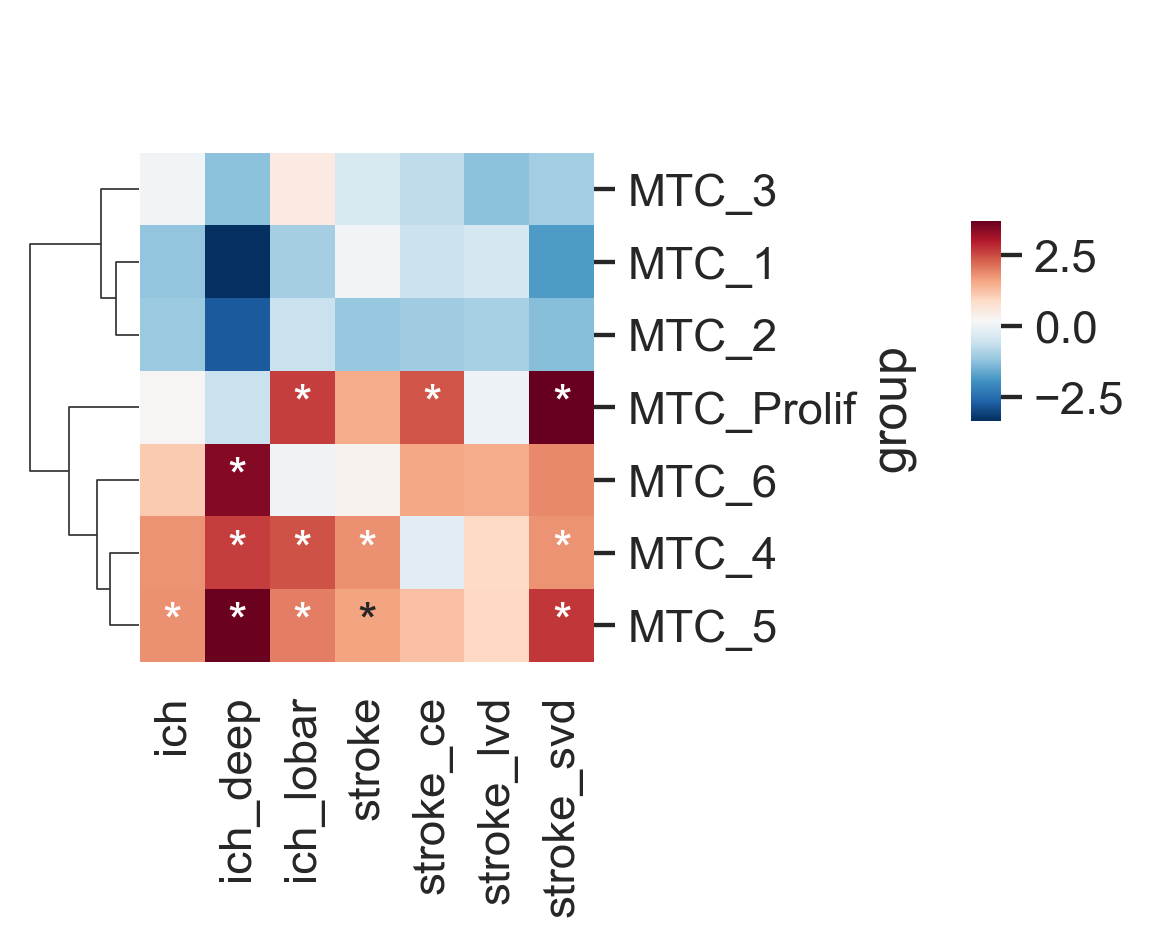

In [38]:
os.chdir('/Users/dimitrioskyriakis/Documents/Projects/ICH_project/results/2024_04_01_scDRS/traits/summary/')

Not_stroke = stroke_columns
files=[f"Metacells_identity_{trait}_summary.csv" for trait in Not_stroke]
tbls = []
nms = []
for file in files:
    f=open(file, 'r')
    tble = pd.read_table(f, sep='\t', on_bad_lines='skip') 
    name=file.replace('Metacells_identity_','')
    name=name.replace('_summary.csv','')
    tbls.append(tble)
    nms.append(name)

df = pd.concat([tble['group']] + [tble['assoc_mcz'] for tble in tbls[:]], axis = 1)
df=df.set_index(df.columns[0])
df.columns=nms
df02=df.copy()

df = pd.concat([tble['group']] + [tble['assoc_mcp'] for tble in tbls[:]], axis = 1)
df=df.set_index(df.columns[0])
df.columns=nms
# df.columns= df.columns.str.split('_').str[0]

df02b=df.copy()
#df=-np.log(df)
df02b=df02b.astype('category')

df02b = df02b.apply(lambda x: ['*' if y <= 0.05 else '' for y in x])


import matplotlib
# matplotlib.use('TkAgg')

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(font_scale=1.2)
ax=sns.clustermap(df02,metric="euclidean", 
                square=True,figsize=(4, 4),col_cluster=False,
               yticklabels=True, cmap='RdBu_r',annot=df02b, fmt = '',
               cbar_pos=(1, 0.55, 0.03, 0.2),
               )  # Adjust the values as needed)
plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90) 

# Save the plot as PDF
ax.savefig("/Users/dimitrioskyriakis/Documents/Projects/ICH_project/Figures/Figure_2E.pdf")


[None, None, None, None, None, None]

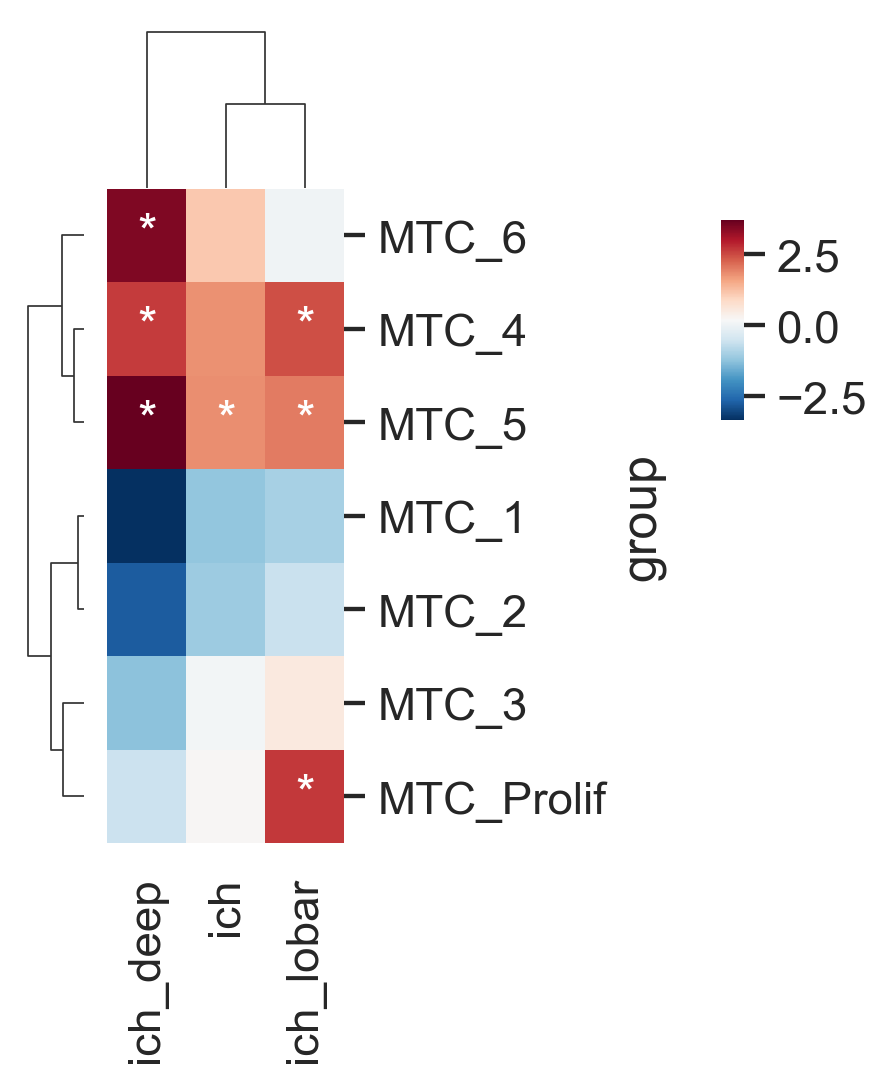

In [39]:
files=[f"Metacells_identity_{trait}_summary.csv" for trait in ich_dict_gs.keys()]
tbls = []
nms = []
for file in files:
    
    
    
    f=open(file, 'r')
    tble = pd.read_table(f, sep='\t', on_bad_lines='skip') 
    
    name=file.replace('Metacells_identity_','')
    name=name.replace('_summary.csv','')
    
    tbls.append(tble)
    nms.append(name)

df = pd.concat([tble['group']] + [tble['assoc_mcz'] for tble in tbls[:]], axis = 1)
df=df.set_index(df.columns[0])
df.columns=nms
# df.columns= df.columns.str.split('_').str[0]

df02=df.copy()
#df=-np.log(df)


df = pd.concat([tble['group']] + [tble['assoc_mcp'] for tble in tbls[:]], axis = 1)
df=df.set_index(df.columns[0])
df.columns=nms
# df.columns= df.columns.str.split('_').str[0]

df02b=df.copy()
#df=-np.log(df)
df02b=df02b.astype('category')

df02b = df02b.apply(lambda x: ['*' if y <= 0.05 else '' for y in x])


import matplotlib
# matplotlib.use('TkAgg')

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(font_scale=1.2)
ax=sns.clustermap(df02,metric="euclidean", 
                square=True,figsize=(3, 4),
               yticklabels=True, cmap='RdBu_r',annot=df02b, fmt = '',
               cbar_pos=(1, 0.55, 0.03, 0.2))  
plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90) 

In [40]:
dict_df_stats.keys()

dict_keys([])

In [41]:
Not_stroke

['ich',
 'ich_deep',
 'ich_lobar',
 'stroke',
 'stroke_ce',
 'stroke_lvd',
 'stroke_svd']

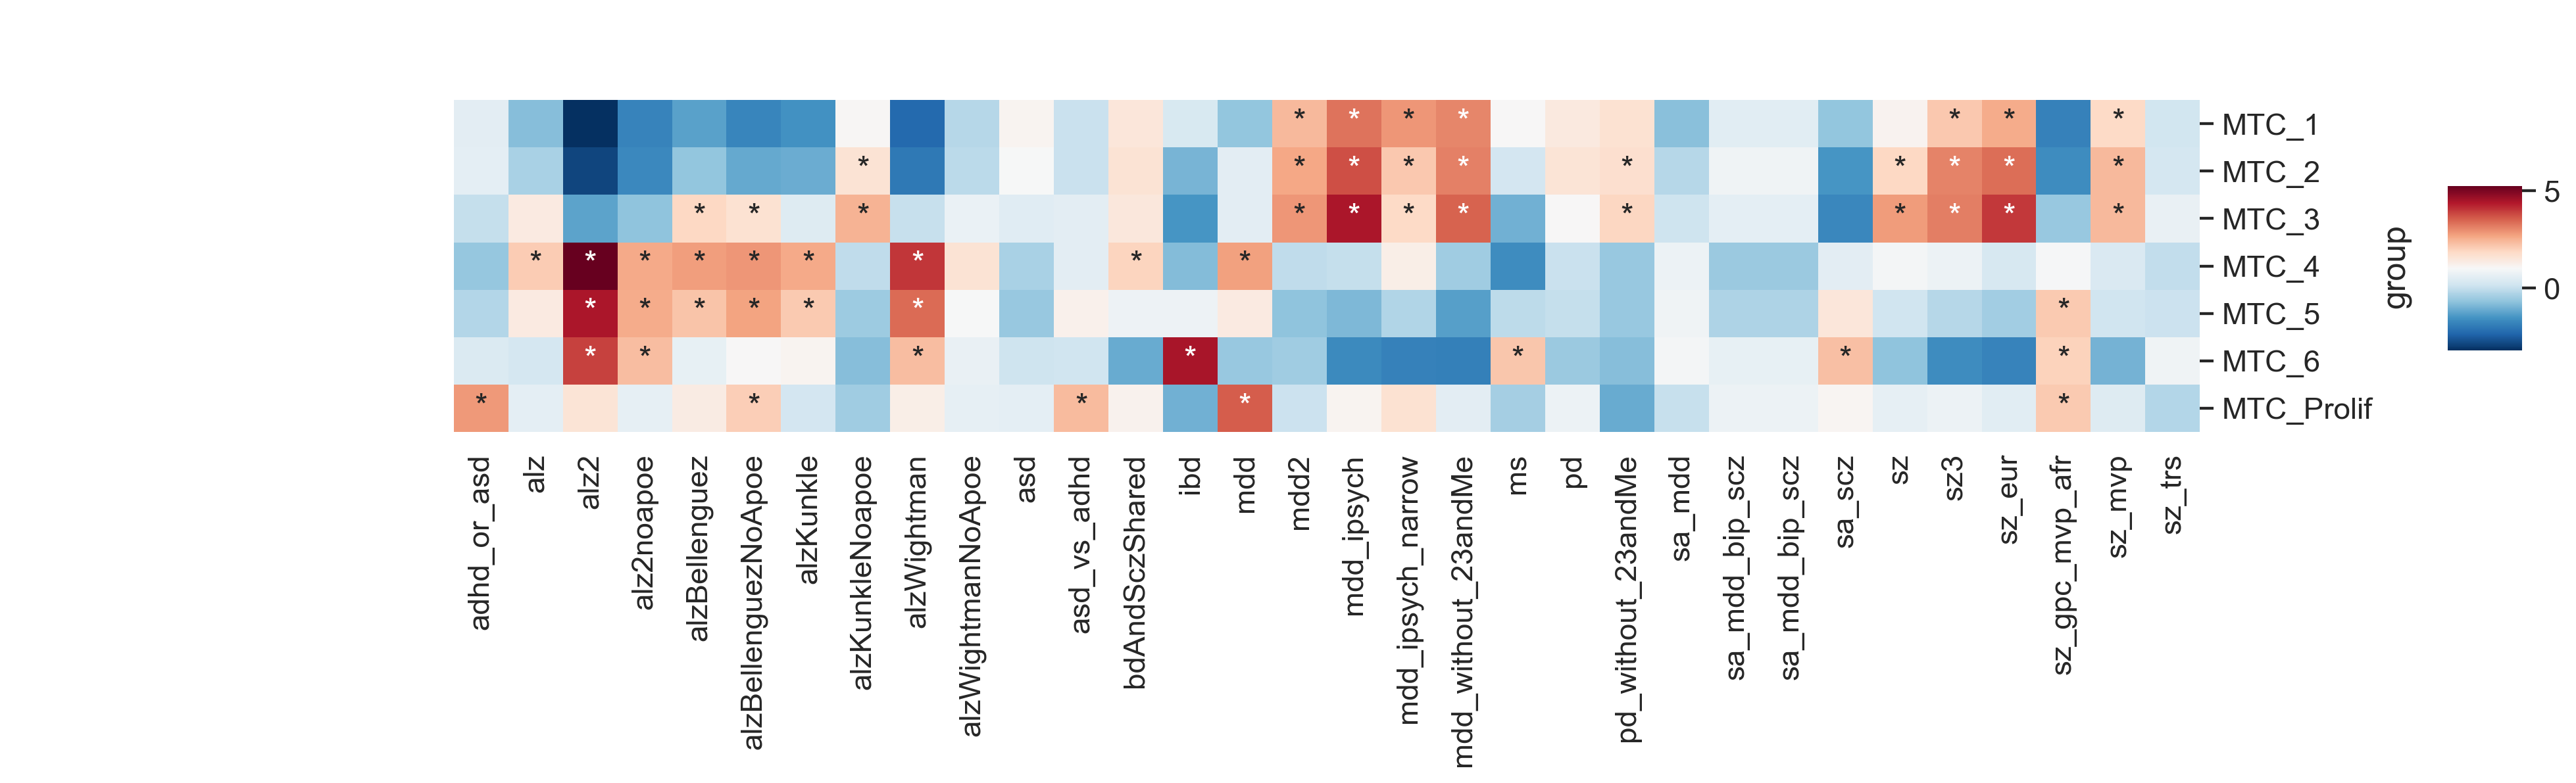

In [44]:
#Not_stroke = dict_df_stats.keys()- stroke_columns


Not_stroke = alz_columns +scz_columns + mdd_columns+ asd_columns+pd_columns+ms_columns+bd_columns


files=[f"Metacells_identity_{trait}_summary.csv" for trait in Not_stroke]
tbls = []
nms = []
for file in files:
    f=open(file, 'r')
    tble = pd.read_table(f, sep='\t', on_bad_lines='skip') 
    name=file.replace('Metacells_identity_','')
    name=name.replace('_summary.csv','')
    tbls.append(tble)
    nms.append(name)

df = pd.concat([tble['group']] + [tble['assoc_mcz'] for tble in tbls[:]], axis = 1)
df=df.set_index(df.columns[0])
df.columns=nms
df = df.sort_index(axis=1)


df02=df.copy()

df = pd.concat([tble['group']] + [tble['assoc_mcp'] for tble in tbls[:]], axis = 1)
df=df.set_index(df.columns[0])
df.columns=nms
df = df.sort_index(axis=1)

# df.columns= df.columns.str.split('_').str[0]

df02b=df.copy()
#df=-np.log(df)
df02b=df02b.astype('category')

df02b = df02b.apply(lambda x: ['*' if y <= 0.05 else '' for y in x])


import matplotlib
# matplotlib.use('TkAgg')

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# df02 = df02.sort_index(axis=1)

sns.set(font_scale=1.2)
ax=sns.clustermap(df02,metric="euclidean", 
                square=True,figsize=(15, 5),col_cluster=False,row_cluster=False,
               yticklabels=True, cmap='RdBu_r',annot=df02b, fmt = '',
               cbar_pos=(1, 0.55, 0.03, 0.2))  # Adjust the values as needed)
plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90) 

ax.savefig("ICH_project/Supp_Figures/Sup.Fig_3C.pdf")



In [45]:
import session_info
session_info.show()

In [46]:
%%R
sessionInfo()


R version 4.3.1 (2023-06-16)
Platform: aarch64-apple-darwin20 (64-bit)
Running under: macOS Ventura 13.4.1

Matrix products: default
BLAS:   /System/Library/Frameworks/Accelerate.framework/Versions/A/Frameworks/vecLib.framework/Versions/A/libBLAS.dylib 
LAPACK: /Library/Frameworks/R.framework/Versions/4.3-arm64/Resources/lib/libRlapack.dylib;  LAPACK version 3.11.0

locale:
[1] C/UTF-8/C/C/C/C

time zone: Europe/Athens
tzcode source: internal

attached base packages:
[1] tools     stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
[1] Seurat_5.0.1         SeuratObject_5.0.1   sp_2.0-0            
[4] zellkonverter_1.10.1

loaded via a namespace (and not attached):
  [1] RColorBrewer_1.1-3          jsonlite_1.8.7             
  [3] magrittr_2.0.3              spatstat.utils_3.0-3       
  [5] zlibbioc_1.46.0             vctrs_0.6.3                
  [7] ROCR_1.0-11                 spatstat.explore_3.2-1     
  [9] RCurl_1.98-1.12         